# Introduction to Image Processing and CNNs

Welcome! 👋 Today we'll explore how computers "see" and process images, from the absolute basics to modern deep learning.

**This tutorial is designed for beginners** - we'll explain everything step by step, even concepts that might seem obvious. Don't skip the explanations!

---

## What You'll Learn:

1. **🖼️ How Computers "See" Images** - What an image really is to a computer (hint: it's just numbers!)
2. **🔧 Classic Image Processing** - Filters, edge detection, and the convolution operation
3. **🧠 Convolutional Neural Networks (CNNs)** - How they work and why they're so powerful for images
4. **🎛️ Hyperparameter Exploration** - See how different settings affect what the network learns
5. **✏️ Hands-on Exercise** - Build your own image classifier!

---

## Prerequisites
- Basic Python knowledge (loops, functions, arrays)
- Some familiarity with neural networks (we'll recap briefly)
- Curiosity! 🎉


In [36]:
# First, let's install and import all the libraries we need
# Run this cell first! (It may take a minute to install packages)

# Uncomment the line below if you need to install packages:
# !pip install numpy matplotlib opencv-python torch torchvision pillow

import numpy as np          # For working with arrays/matrices of numbers
import matplotlib.pyplot as plt  # For creating visualizations
import cv2                  # OpenCV - a popular image processing library
from PIL import Image       # Another image library (Python Imaging Library)
import torch                # PyTorch - deep learning framework
import torch.nn as nn       # Neural network building blocks
import torch.nn.functional as F  # Neural network functions
import torchvision          # Computer vision utilities for PyTorch
import torchvision.transforms as transforms  # Image transformations
from torchvision.datasets import MNIST  # Famous handwritten digits dataset
from torch.utils.data import DataLoader  # For loading data in batches

# Set random seeds so we all get the same results
np.random.seed(42)
torch.manual_seed(42)

print("✅ All imports successful! Let's learn about images!")


✅ All imports successful! Let's learn about images!


---
# Part 1: How Computers "See" Images 🖼️

Before we can process images or build neural networks, we need to understand a fundamental question:

## **How does a computer actually "see" an image?**

When you look at a photo, you see faces, objects, colors, and meaning. But a computer doesn't "see" anything - it only understands **numbers**.

**Key Insight**: To a computer, every image is just a big grid (matrix) of numbers!

Let's explore this step by step.


## 1.1 What is a Pixel?

The word **pixel** comes from "picture element." It's the smallest unit of a digital image.

Think of an image like a mosaic:
- A mosaic is made of tiny colored tiles
- A digital image is made of tiny colored squares called pixels

Each pixel has ONE color. When you zoom in enough on any digital image, you'll see these individual squares.


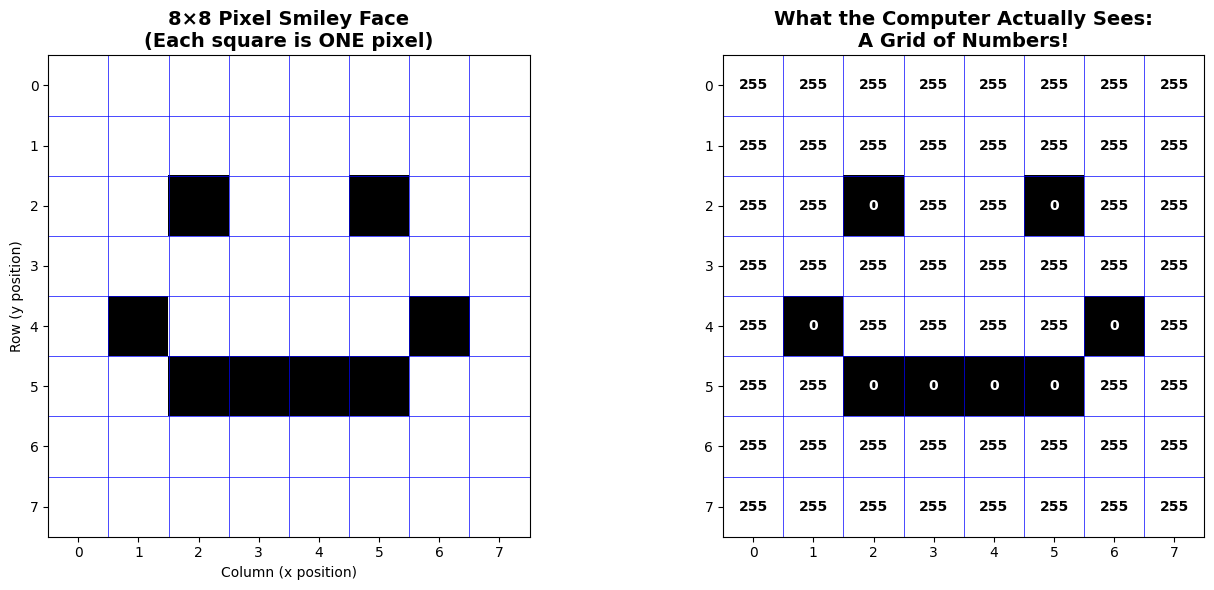

🔍 IMPORTANT OBSERVATION:
   • The image on the LEFT is what WE see (a smiley face)
   • The numbers on the RIGHT is what the COMPUTER sees (just numbers!)
   • 255 = white, 0 = black

   This image has 64 = 64 total pixels


In [37]:
# Let's create a tiny 8x8 pixel image to understand how pixels work
# We'll create a simple smiley face! 😊

# Create an 8x8 grid filled with white (255 = white, 0 = black)
tiny_image = np.ones((8, 8), dtype=np.uint8) * 255

# Add some black pixels to make a face
# Eyes (row 2, columns 2 and 5)
tiny_image[2, 2] = 0   # Left eye
tiny_image[2, 5] = 0   # Right eye

# Mouth (row 5, columns 2-5)
tiny_image[5, 2] = 0
tiny_image[5, 3] = 0
tiny_image[5, 4] = 0
tiny_image[5, 5] = 0

# Row 4, columns 1 and 6 (corners of smile)
tiny_image[4, 1] = 0
tiny_image[4, 6] = 0

# Let's visualize this tiny image and its pixel values
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Show the image (zoomed in so we can see pixels)
axes[0].imshow(tiny_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('8×8 Pixel Smiley Face\n(Each square is ONE pixel)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Column (x position)')
axes[0].set_ylabel('Row (y position)')

# Add grid lines to show individual pixels
for i in range(9):
    axes[0].axhline(y=i-0.5, color='blue', linewidth=0.5)
    axes[0].axvline(x=i-0.5, color='blue', linewidth=0.5)

# Right: Show the actual numbers in each pixel
axes[1].imshow(tiny_image, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('What the Computer Actually Sees:\nA Grid of Numbers!', fontsize=14, fontweight='bold')

# Display the numeric value in each cell
for i in range(8):
    for j in range(8):
        color = 'white' if tiny_image[i, j] < 128 else 'black'
        axes[1].text(j, i, str(tiny_image[i, j]), ha='center', va='center', 
                    fontsize=10, color=color, fontweight='bold')

# Add grid
for i in range(9):
    axes[1].axhline(y=i-0.5, color='blue', linewidth=0.5)
    axes[1].axvline(x=i-0.5, color='blue', linewidth=0.5)

plt.tight_layout()
plt.show()

print("🔍 IMPORTANT OBSERVATION:")
print("   • The image on the LEFT is what WE see (a smiley face)")
print("   • The numbers on the RIGHT is what the COMPUTER sees (just numbers!)")
print("   • 255 = white, 0 = black")
print(f"\n   This image has {8*8} = 64 total pixels")


## 1.2 Grayscale Images: Shades of Gray

In a **grayscale** (black and white) image:
- Each pixel is a single number between **0** and **255**
- **0** = pure black (no light)
- **255** = pure white (maximum light)  
- Numbers in between = shades of gray

This number is sometimes called the pixel's **intensity** or **brightness**.

**Why 0-255?** Because computers store these values in 8 bits, and 2⁸ = 256 possible values (0 to 255).


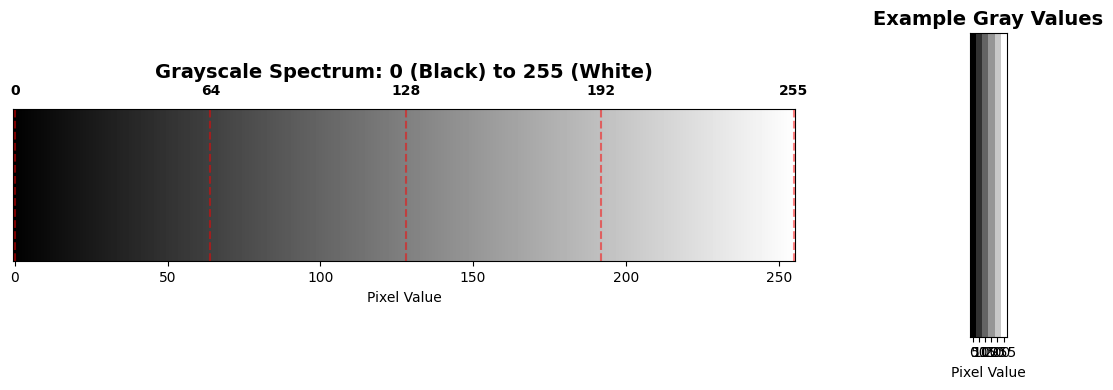

💡 Think of it like a dimmer switch:
   • 0 = lights completely off (black)
   • 128 = lights at half brightness (medium gray)
   • 255 = lights at full brightness (white)


In [38]:
# Let's visualize the grayscale spectrum (0=black to 255=white)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Create a gradient from black to white
gradient = np.linspace(0, 255, 256).reshape(1, -1).astype(np.uint8)
gradient = np.repeat(gradient, 50, axis=0)  # Make it taller for visibility

# Show the gradient
axes[0].imshow(gradient, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Grayscale Spectrum: 0 (Black) to 255 (White)\n', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Pixel Value')
axes[0].set_yticks([])

# Add some value labels
for val in [0, 64, 128, 192, 255]:
    axes[0].axvline(x=val, color='red', linestyle='--', alpha=0.5)
    axes[0].text(val, -5, str(val), ha='center', fontsize=10, fontweight='bold')

# Show examples of specific gray values
example_values = [0, 50, 100, 150, 200, 255]
example_colors = np.array([[v] * 50 for v in example_values]).T.astype(np.uint8)

axes[1].imshow(example_colors, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Example Gray Values', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(example_values)))
axes[1].set_xticklabels(example_values)
axes[1].set_xlabel('Pixel Value')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print("💡 Think of it like a dimmer switch:")
print("   • 0 = lights completely off (black)")
print("   • 128 = lights at half brightness (medium gray)")
print("   • 255 = lights at full brightness (white)")


## 1.3 Color Images: RGB Channels

Color images are more complex. Each pixel needs THREE numbers to describe its color:

- **R** = Red intensity (0-255)
- **G** = Green intensity (0-255)  
- **B** = Blue intensity (0-255)

By mixing different amounts of red, green, and blue light, we can create any color!

**Examples:**
- Red: (255, 0, 0) - full red, no green, no blue
- Green: (0, 255, 0)
- Blue: (0, 0, 255)
- Yellow: (255, 255, 0) - red + green = yellow
- White: (255, 255, 255) - all colors at full
- Black: (0, 0, 0) - no light at all


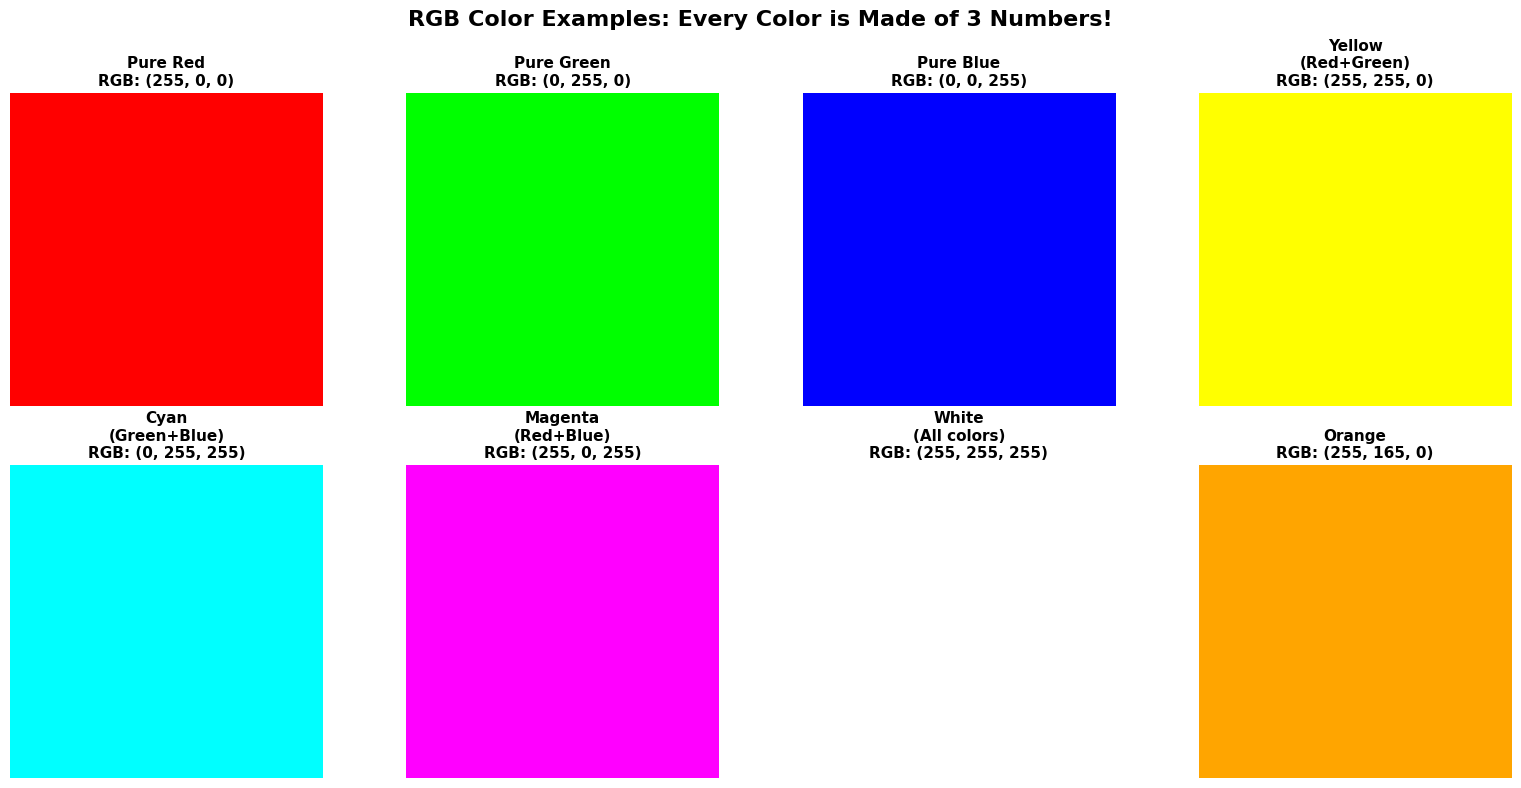

🎨 Key Insight:
   • Each pixel in a color image has 3 values: (R, G, B)
   • These values range from 0 to 255
   • By mixing different amounts, we can create ~16.7 million colors!
   • (256 × 256 × 256 = 16,777,216 possible colors)


In [39]:
# Let's visualize how RGB color mixing works! 🎨

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Define some colors with their RGB values
colors = [
    ('Pure Red', (255, 0, 0)),
    ('Pure Green', (0, 255, 0)),
    ('Pure Blue', (0, 0, 255)),
    ('Yellow\n(Red+Green)', (255, 255, 0)),
    ('Cyan\n(Green+Blue)', (0, 255, 255)),
    ('Magenta\n(Red+Blue)', (255, 0, 255)),
    ('White\n(All colors)', (255, 255, 255)),
    ('Orange', (255, 165, 0)),
]

for idx, (name, rgb) in enumerate(colors):
    row = idx // 4
    col = idx % 4
    
    # Create a small colored square
    color_square = np.zeros((50, 50, 3), dtype=np.uint8)
    color_square[:, :] = rgb
    
    axes[row, col].imshow(color_square)
    axes[row, col].set_title(f'{name}\nRGB: {rgb}', fontsize=11, fontweight='bold')
    axes[row, col].axis('off')

plt.suptitle('RGB Color Examples: Every Color is Made of 3 Numbers!', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("🎨 Key Insight:")
print("   • Each pixel in a color image has 3 values: (R, G, B)")
print("   • These values range from 0 to 255")
print("   • By mixing different amounts, we can create ~16.7 million colors!")
print("   • (256 × 256 × 256 = 16,777,216 possible colors)")


## 1.4 Image Dimensions: Height × Width × Channels

Now let's put it all together. An image is stored as a **multi-dimensional array** (tensor):

**Grayscale Image:**
- Shape: `(Height, Width)` 
- Example: A 100×100 grayscale image has shape `(100, 100)`
- Total numbers: 100 × 100 = 10,000 values

**Color Image:**
- Shape: `(Height, Width, 3)` for RGB
- Example: A 100×100 color image has shape `(100, 100, 3)`
- Total numbers: 100 × 100 × 3 = 30,000 values

This is why color images take 3x more storage than grayscale!


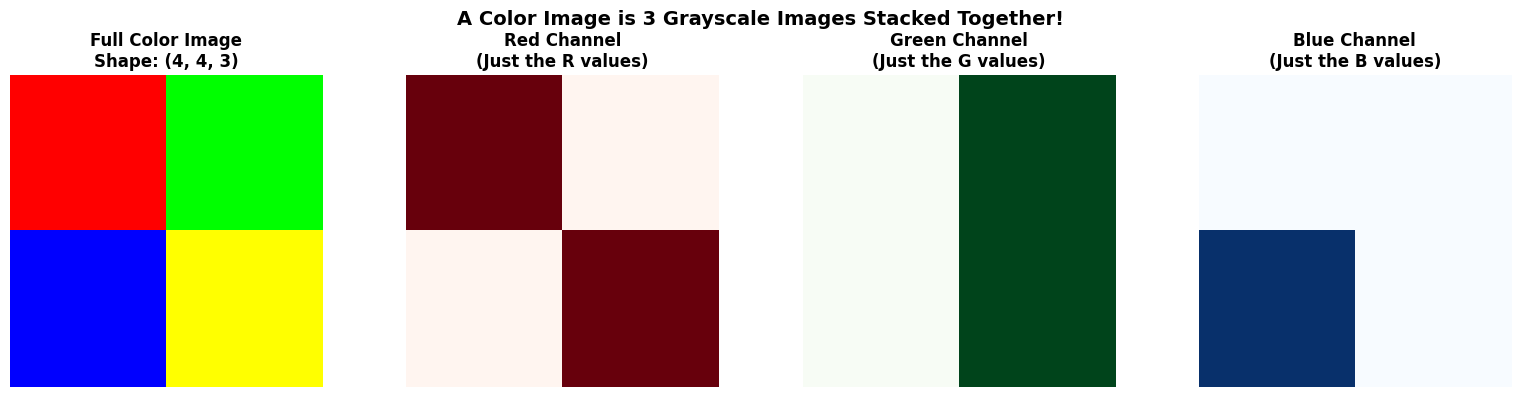

📊 Image Shape Analysis:
   • Shape: (4, 4, 3)
   • This means: 4 rows × 4 columns × 3 channels
   • Total numbers stored: 4 × 4 × 3 = 48

📍 Let's look at one pixel (row 0, column 0 - top left):
   • Full RGB value: [255   0   0]
   • Red: 255, Green: 0, Blue: 0
   • This is pure RED!


In [40]:
# Let's create a color image and examine its structure 🖼️

# Create a simple 4x4 color image with different colored squares
color_image = np.zeros((4, 4, 3), dtype=np.uint8)

# Top-left: Red
color_image[0:2, 0:2] = [255, 0, 0]  # RGB for red

# Top-right: Green  
color_image[0:2, 2:4] = [0, 255, 0]  # RGB for green

# Bottom-left: Blue
color_image[2:4, 0:2] = [0, 0, 255]  # RGB for blue

# Bottom-right: Yellow
color_image[2:4, 2:4] = [255, 255, 0]  # RGB for yellow

# Visualize the image and its three channels
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# The full color image
axes[0].imshow(color_image)
axes[0].set_title(f'Full Color Image\nShape: {color_image.shape}', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Red channel only
axes[1].imshow(color_image[:, :, 0], cmap='Reds', vmin=0, vmax=255)
axes[1].set_title('Red Channel\n(Just the R values)', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Green channel only
axes[2].imshow(color_image[:, :, 1], cmap='Greens', vmin=0, vmax=255)
axes[2].set_title('Green Channel\n(Just the G values)', fontsize=12, fontweight='bold')
axes[2].axis('off')

# Blue channel only
axes[3].imshow(color_image[:, :, 2], cmap='Blues', vmin=0, vmax=255)
axes[3].set_title('Blue Channel\n(Just the B values)', fontsize=12, fontweight='bold')
axes[3].axis('off')

plt.suptitle('A Color Image is 3 Grayscale Images Stacked Together!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the actual numbers
print("📊 Image Shape Analysis:")
print(f"   • Shape: {color_image.shape}")
print(f"   • This means: {color_image.shape[0]} rows × {color_image.shape[1]} columns × {color_image.shape[2]} channels")
print(f"   • Total numbers stored: {color_image.shape[0]} × {color_image.shape[1]} × {color_image.shape[2]} = {color_image.size}")

print("\n📍 Let's look at one pixel (row 0, column 0 - top left):")
print(f"   • Full RGB value: {color_image[0, 0]}")
print(f"   • Red: {color_image[0, 0, 0]}, Green: {color_image[0, 0, 1]}, Blue: {color_image[0, 0, 2]}")
print(f"   • This is pure RED!")


## 1.5 Summary: What is an Image to a Computer?

Let's recap what we've learned:

| Image Type | What Each Pixel Contains | Shape | Example (100×100) |
|------------|-------------------------|-------|-------------------|
| **Grayscale** | 1 number (brightness 0-255) | (H, W) | 10,000 numbers |
| **Color (RGB)** | 3 numbers (R, G, B each 0-255) | (H, W, 3) | 30,000 numbers |

**🧠 The Key Insight for Machine Learning:**
- To a computer, an image is just a big array of numbers
- This means we can apply mathematical operations to images!
- We can feed these numbers into neural networks!
- The challenge: How do we extract meaningful patterns from thousands of numbers?

This is exactly what image processing and CNNs are designed to solve!

---

# Part 2: Classic Image Processing 🔧

Before deep learning existed, computer vision researchers developed **hand-crafted algorithms** to process images. These techniques are still useful today, and understanding them helps us understand CNNs!

The most important operation in image processing is called **convolution**.


## 2.1 What is Convolution?

**Convolution** might sound complicated, but it's actually a simple idea:

Imagine you have a small "window" (called a **kernel** or **filter**) that you slide across an image. At each position, you:
1. Look at the pixels under the window
2. Multiply them by numbers in the window
3. Add up all the results
4. That sum becomes one pixel in the output

**Think of it like this:** The kernel is like a pattern detector. It looks at small patches of the image and asks "how much does this patch match my pattern?"

### Why is this useful?

Different kernels detect different things:
- Some kernels detect **edges** (boundaries between light and dark)
- Some kernels **blur** the image (average nearby pixels)
- Some kernels **sharpen** the image (enhance details)

Let's see this in action!


CONVOLUTION STEP-BY-STEP EXAMPLE

📥 INPUT IMAGE (5×5):
   (0 = dark, 1 = bright)
   This is a white square on a dark background:

[[0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0.]]

📐 KERNEL/FILTER (3×3):
   This kernel is designed to detect VERTICAL edges:
   (left side negative, right side positive)

[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]

NOW LET'S DO THE MATH!

🔢 Calculating output position [0, 0]:
   We place the 3×3 kernel at the TOP-LEFT of the image

   Image region under kernel:
[[0. 0. 0.]
 [0. 1. 1.]
 [0. 1. 1.]]

   Kernel:
[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]

   Step 1: Multiply each image pixel by the corresponding kernel value
[[-0.  0.  0.]
 [-0.  0.  1.]
 [-0.  0.  1.]]

   Step 2: Add them all up: 2

----------------------------------------
We repeat this for all positions...
----------------------------------------

📤 FINAL OUTPUT (3×3):
[[ 2.  0. -2.]
 [ 3.  0. -3.]
 [ 2.  0. -2.]]


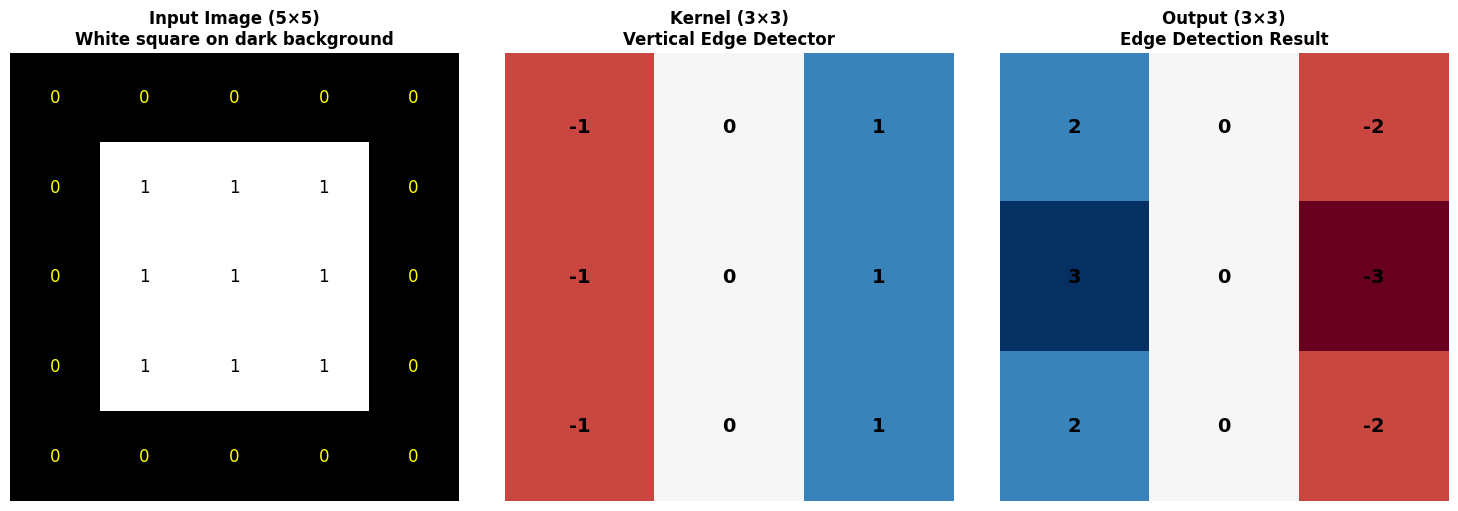


💡 INTERPRETATION:
   • Left column shows NEGATIVE values (-3): Left edge detected!
   • Middle column shows ZERO: No vertical edge here
   • Right column shows POSITIVE values (+3): Right edge detected!

   The kernel found the vertical edges of the square!


In [41]:
# Let's visualize convolution step by step with a simple example 🔍

def visualize_convolution_step_by_step():
    """Show exactly how convolution works, one step at a time"""
    
    # Create a simple 5x5 input image (think of these as brightness values)
    input_image = np.array([
        [0, 0, 0, 0, 0],
        [0, 1, 1, 1, 0],
        [0, 1, 1, 1, 0],
        [0, 1, 1, 1, 0],
        [0, 0, 0, 0, 0]
    ], dtype=float)
    
    # Create a 3x3 kernel (this one will detect vertical edges)
    kernel = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=float)
    
    print("=" * 60)
    print("CONVOLUTION STEP-BY-STEP EXAMPLE")
    print("=" * 60)
    
    print("\n📥 INPUT IMAGE (5×5):")
    print("   (0 = dark, 1 = bright)")
    print("   This is a white square on a dark background:\n")
    print(input_image)
    
    print("\n📐 KERNEL/FILTER (3×3):")
    print("   This kernel is designed to detect VERTICAL edges:")
    print("   (left side negative, right side positive)\n")
    print(kernel)
    
    # Calculate output size: (5-3+1) = 3
    output = np.zeros((3, 3))
    
    print("\n" + "=" * 60)
    print("NOW LET'S DO THE MATH!")
    print("=" * 60)
    
    # Show calculation for position (0, 0)
    print("\n🔢 Calculating output position [0, 0]:")
    print("   We place the 3×3 kernel at the TOP-LEFT of the image")
    print("\n   Image region under kernel:")
    region = input_image[0:3, 0:3]
    print(region)
    print("\n   Kernel:")
    print(kernel)
    print("\n   Step 1: Multiply each image pixel by the corresponding kernel value")
    elementwise = region * kernel
    print(elementwise)
    print(f"\n   Step 2: Add them all up: {elementwise.sum():.0f}")
    output[0, 0] = elementwise.sum()
    
    print("\n" + "-" * 40)
    print("We repeat this for all positions...")
    print("-" * 40)
    
    # Calculate all positions
    for i in range(3):
        for j in range(3):
            region = input_image[i:i+3, j:j+3]
            output[i, j] = np.sum(region * kernel)
    
    print("\n📤 FINAL OUTPUT (3×3):")
    print(output)
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Input image
    axes[0].imshow(input_image, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Input Image (5×5)\nWhite square on dark background', fontsize=12, fontweight='bold')
    for i in range(5):
        for j in range(5):
            axes[0].text(j, i, f'{input_image[i,j]:.0f}', ha='center', va='center', 
                        color='yellow' if input_image[i,j] < 0.5 else 'black', fontsize=12)
    axes[0].axis('off')
    
    # Kernel
    axes[1].imshow(kernel, cmap='RdBu', vmin=-1.5, vmax=1.5)
    axes[1].set_title('Kernel (3×3)\nVertical Edge Detector', fontsize=12, fontweight='bold')
    for i in range(3):
        for j in range(3):
            axes[1].text(j, i, f'{kernel[i,j]:.0f}', ha='center', va='center', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # Output
    axes[2].imshow(output, cmap='RdBu', vmin=-3, vmax=3)
    axes[2].set_title('Output (3×3)\nEdge Detection Result', fontsize=12, fontweight='bold')
    for i in range(3):
        for j in range(3):
            axes[2].text(j, i, f'{output[i,j]:.0f}', ha='center', va='center', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 INTERPRETATION:")
    print("   • Left column shows NEGATIVE values (-3): Left edge detected!")
    print("   • Middle column shows ZERO: No vertical edge here")
    print("   • Right column shows POSITIVE values (+3): Right edge detected!")
    print("\n   The kernel found the vertical edges of the square!")

visualize_convolution_step_by_step()


---

## 2.2 Classic Kernels: Different Tools for Different Jobs

Over decades, researchers discovered that different kernel patterns are useful for different tasks.

Let's look at some famous kernels:


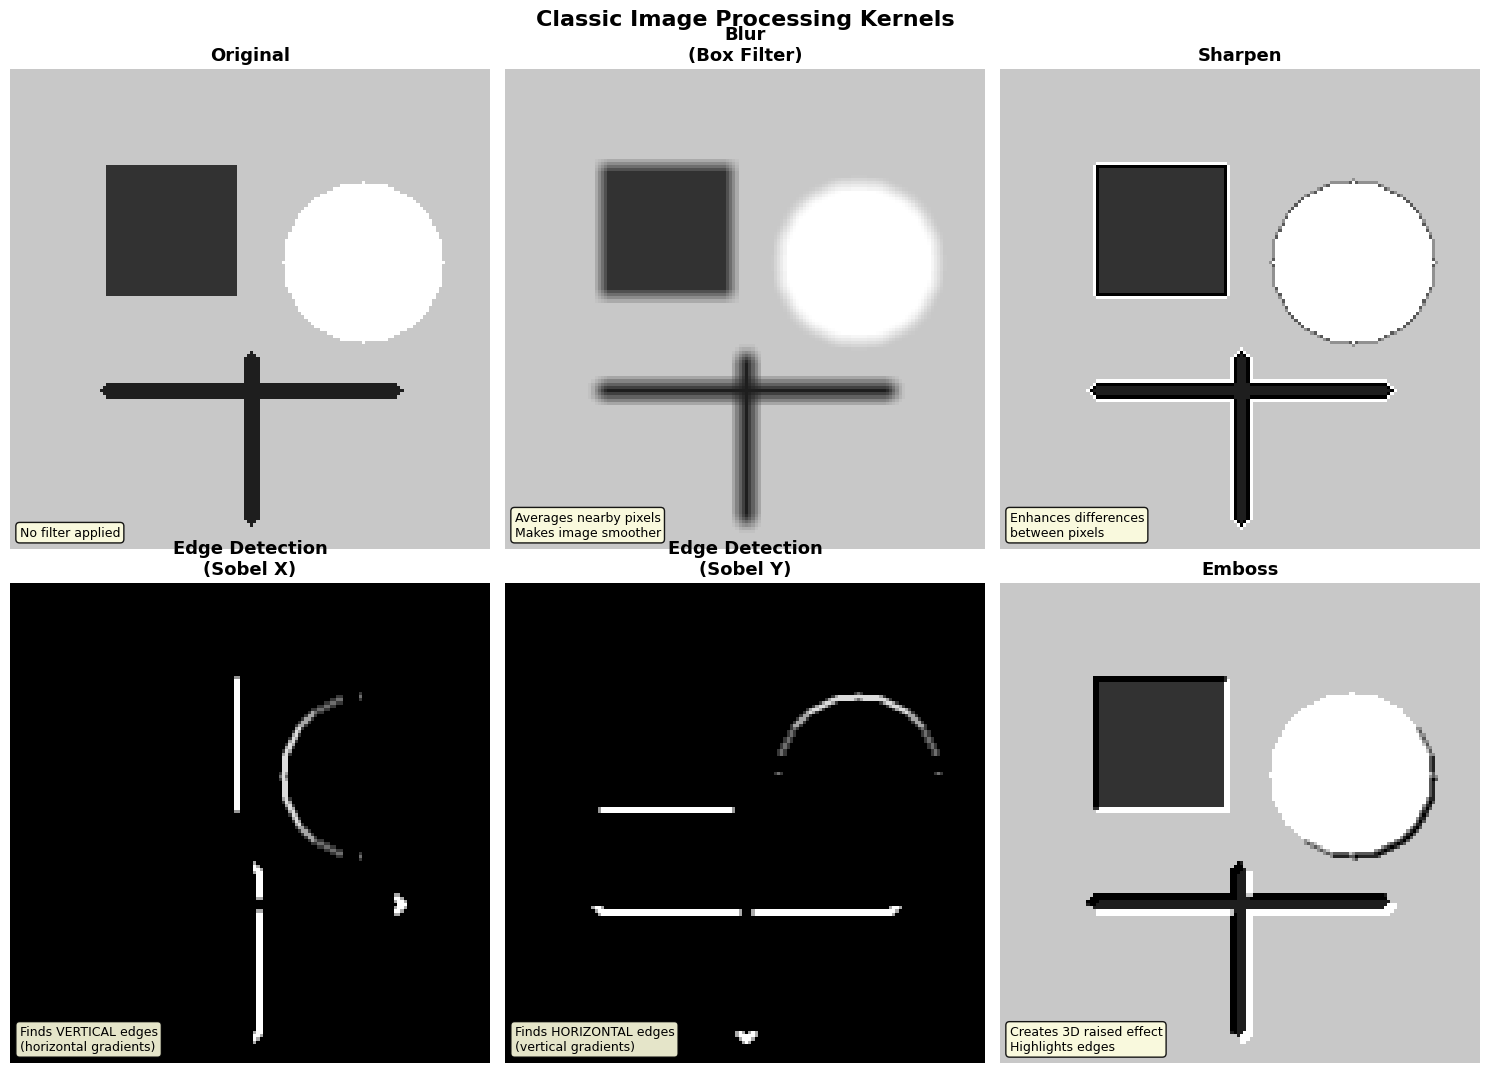

💡 KEY INSIGHT:
   These kernels were HAND-DESIGNED by humans over many years.
   Engineers had to figure out what patterns would detect edges, blur images, etc.

🧠 What if a computer could LEARN the best kernels automatically?
   That's exactly what CNNs do!


In [42]:
# Create a sample image with clear features to demonstrate kernels 🎯
def create_sample_image():
    """Create a simple test image with geometric shapes"""
    img = np.ones((150, 150), dtype=np.uint8) * 200  # Light gray background
    
    # Draw a dark rectangle
    cv2.rectangle(img, (30, 30), (70, 70), 50, -1)
    
    # Draw a white circle
    cv2.circle(img, (110, 60), 25, 255, -1)
    
    # Draw some lines
    cv2.line(img, (30, 100), (120, 100), 30, 3)
    cv2.line(img, (75, 90), (75, 140), 30, 3)
    
    return img

sample_image = create_sample_image()

# Define classic kernels with explanations
kernels = {
    'Original': {
        'kernel': None,
        'explanation': 'No filter applied'
    },
    'Blur\n(Box Filter)': {
        'kernel': np.ones((5, 5), np.float32) / 25,
        'explanation': 'Averages nearby pixels\nMakes image smoother'
    },
    'Sharpen': {
        'kernel': np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]], dtype=np.float32),
        'explanation': 'Enhances differences\nbetween pixels'
    },
    'Edge Detection\n(Sobel X)': {
        'kernel': np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]], dtype=np.float32),
        'explanation': 'Finds VERTICAL edges\n(horizontal gradients)'
    },
    'Edge Detection\n(Sobel Y)': {
        'kernel': np.array([[-1, -2, -1],
                           [0, 0, 0],
                           [1, 2, 1]], dtype=np.float32),
        'explanation': 'Finds HORIZONTAL edges\n(vertical gradients)'
    },
    'Emboss': {
        'kernel': np.array([[-2, -1, 0],
                           [-1, 1, 1],
                           [0, 1, 2]], dtype=np.float32),
        'explanation': 'Creates 3D raised effect\nHighlights edges'
    }
}

# Apply each kernel and show results
fig, axes = plt.subplots(2, 3, figsize=(15, 11))
axes = axes.flatten()

for idx, (name, data) in enumerate(kernels.items()):
    kernel = data['kernel']
    explanation = data['explanation']
    
    if kernel is None:
        result = sample_image
    else:
        result = cv2.filter2D(sample_image, -1, kernel)
    
    axes[idx].imshow(result, cmap='gray', vmin=0, vmax=255)
    axes[idx].set_title(name, fontsize=13, fontweight='bold')
    axes[idx].axis('off')
    
    # Add explanation box
    axes[idx].text(0.02, 0.02, explanation, transform=axes[idx].transAxes,
                  fontsize=9, verticalalignment='bottom',
                  bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.suptitle('Classic Image Processing Kernels', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("💡 KEY INSIGHT:")
print("   These kernels were HAND-DESIGNED by humans over many years.")
print("   Engineers had to figure out what patterns would detect edges, blur images, etc.")
print("\n🧠 What if a computer could LEARN the best kernels automatically?")
print("   That's exactly what CNNs do!")


---

# Part 3: Convolutional Neural Networks (CNNs) 🧠

Now we get to the exciting part! **CNNs combine the power of convolution with neural networks.**

## 3.1 The Big Idea: Learning Kernels Instead of Hand-Designing Them

Remember those kernels we just saw? (edge detection, blur, sharpen, etc.)

**The problem with hand-crafted kernels:**
- Humans had to invent them through trial and error
- They're limited to simple patterns
- Different tasks need different kernels - hard to know which ones!

**The CNN solution:**
- Start with random kernels
- Show the network many examples (images with labels)
- The network adjusts the kernel values to minimize errors
- Eventually, it LEARNS kernels that are perfect for the task!

**This is just like how a regular neural network learns weights, but now we're learning convolution kernels!**


## 3.2 Why CNNs are Better Than Regular Neural Networks for Images

You might wonder: **Why not just use a regular fully-connected neural network for images?**

Let's see why that's a bad idea:

**Problem 1: Too Many Parameters!**
- A tiny 28×28 grayscale image has 784 pixels
- If your first hidden layer has 100 neurons, you need 784 × 100 = 78,400 weights for just that layer!
- A 224×224 RGB image (standard size) has 224 × 224 × 3 = 150,528 pixels
- With 100 neurons: 15 million weights for ONE layer!

**Problem 2: Loses Spatial Information**
- Regular neural networks treat the image as a flat list of numbers
- They don't know that pixel [0,0] is next to pixel [0,1]
- They can't detect that a pattern in the top-left is the same as in the bottom-right

**CNNs solve both problems:**

| Feature | Regular NN | CNN |
|---------|-----------|-----|
| Parameters | Millions | Thousands |
| Spatial awareness | ❌ None | ✅ Yes |
| Translation invariant | ❌ No | ✅ Yes |
| Can detect local patterns | ❌ Hard | ✅ Easy |


## 3.3 CNN Building Blocks

A typical CNN has four types of layers. Let's understand each one:

### Layer Type 1: Convolutional Layer (Conv)
- Applies learnable kernels to detect patterns
- **Input:** Image or feature maps
- **Output:** Feature maps (one per kernel)
- **What it learns:** Patterns like edges, textures, shapes

### Layer Type 2: Activation Function (Usually ReLU)
- Adds non-linearity (without this, stacking layers wouldn't help!)
- **ReLU** = Rectified Linear Unit: `output = max(0, input)`
- Simply turns all negative values to zero
- Fast to compute, works great in practice

### Layer Type 3: Pooling Layer (Usually Max Pooling)
- Reduces the size of feature maps
- Makes the network more efficient
- Makes features more robust to small shifts

### Layer Type 4: Fully Connected Layer (at the end)
- After convolutions, flatten the features
- Use regular neural network layers for final classification

Let's visualize each component!


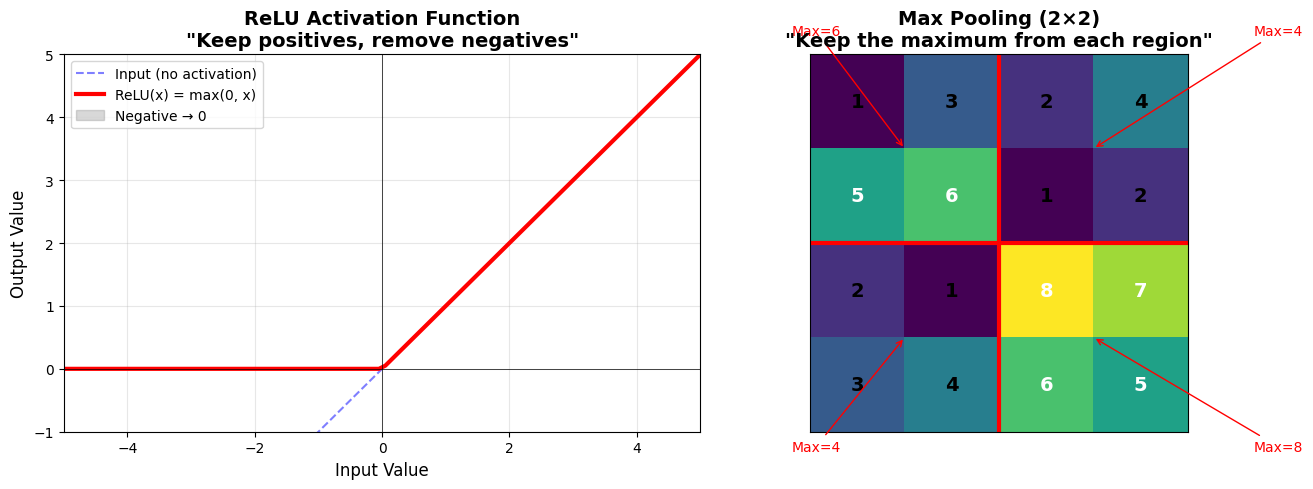

📊 RELU EXPLAINED:
   • Positive numbers stay the same: ReLU(5) = 5
   • Negative numbers become zero: ReLU(-3) = 0
   • This adds non-linearity, allowing the network to learn complex patterns

📊 MAX POOLING EXPLAINED:
   • Divide the feature map into non-overlapping regions (2×2 here)
   • Keep only the maximum value from each region
   • Result: 4×4 → 2×2 (cuts size in half!)
   • Benefits: Reduces computation, provides some translation invariance


In [43]:
# Let's visualize ReLU and Max Pooling 📊

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============ ReLU Visualization ============
x = np.linspace(-5, 5, 100)
y_relu = np.maximum(0, x)  # ReLU function

axes[0].plot(x, x, 'b--', label='Input (no activation)', alpha=0.5)
axes[0].plot(x, y_relu, 'r-', linewidth=3, label='ReLU(x) = max(0, x)')
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[0].fill_between(x[x < 0], y_relu[x < 0], alpha=0.3, color='gray', label='Negative → 0')
axes[0].set_xlabel('Input Value', fontsize=12)
axes[0].set_ylabel('Output Value', fontsize=12)
axes[0].set_title('ReLU Activation Function\n"Keep positives, remove negatives"', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-5, 5)
axes[0].set_ylim(-1, 5)

# ============ Max Pooling Visualization ============
# Create a sample feature map
feature_map = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [2, 1, 8, 7],
    [3, 4, 6, 5]
])

# Show the feature map with pooling regions
im = axes[1].imshow(feature_map, cmap='viridis')
axes[1].set_title('Max Pooling (2×2)\n"Keep the maximum from each region"', fontsize=14, fontweight='bold')

# Add numbers to cells
for i in range(4):
    for j in range(4):
        color = 'white' if feature_map[i, j] > 4 else 'black'
        axes[1].text(j, i, str(feature_map[i, j]), ha='center', va='center', 
                    fontsize=14, fontweight='bold', color=color)

# Draw pooling region boundaries
axes[1].axhline(y=1.5, color='red', linewidth=3)
axes[1].axvline(x=1.5, color='red', linewidth=3)
axes[1].set_xticks([])
axes[1].set_yticks([])

# Add annotations for max values
axes[1].annotate('Max=6', xy=(0.5, 0.5), xytext=(-0.7, -0.7), fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))
axes[1].annotate('Max=4', xy=(2.5, 0.5), xytext=(4.2, -0.7), fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))
axes[1].annotate('Max=4', xy=(0.5, 2.5), xytext=(-0.7, 3.7), fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))
axes[1].annotate('Max=8', xy=(2.5, 2.5), xytext=(4.2, 3.7), fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

print("📊 RELU EXPLAINED:")
print("   • Positive numbers stay the same: ReLU(5) = 5")
print("   • Negative numbers become zero: ReLU(-3) = 0")
print("   • This adds non-linearity, allowing the network to learn complex patterns")

print("\n📊 MAX POOLING EXPLAINED:")
print("   • Divide the feature map into non-overlapping regions (2×2 here)")
print("   • Keep only the maximum value from each region")
print("   • Result: 4×4 → 2×2 (cuts size in half!)")
print("   • Benefits: Reduces computation, provides some translation invariance")


## 3.4 Let's See a Real CNN in Action!

Now let's load a real dataset and build a CNN to classify images.

We'll use **MNIST** - a famous dataset of handwritten digits (0-9).
- 60,000 training images
- 10,000 test images  
- Each image is 28×28 pixels, grayscale
- Labels: the digit shown (0, 1, 2, ..., 9)



✅ Dataset loaded!
   Training images: 60,000
   Test images: 10,000


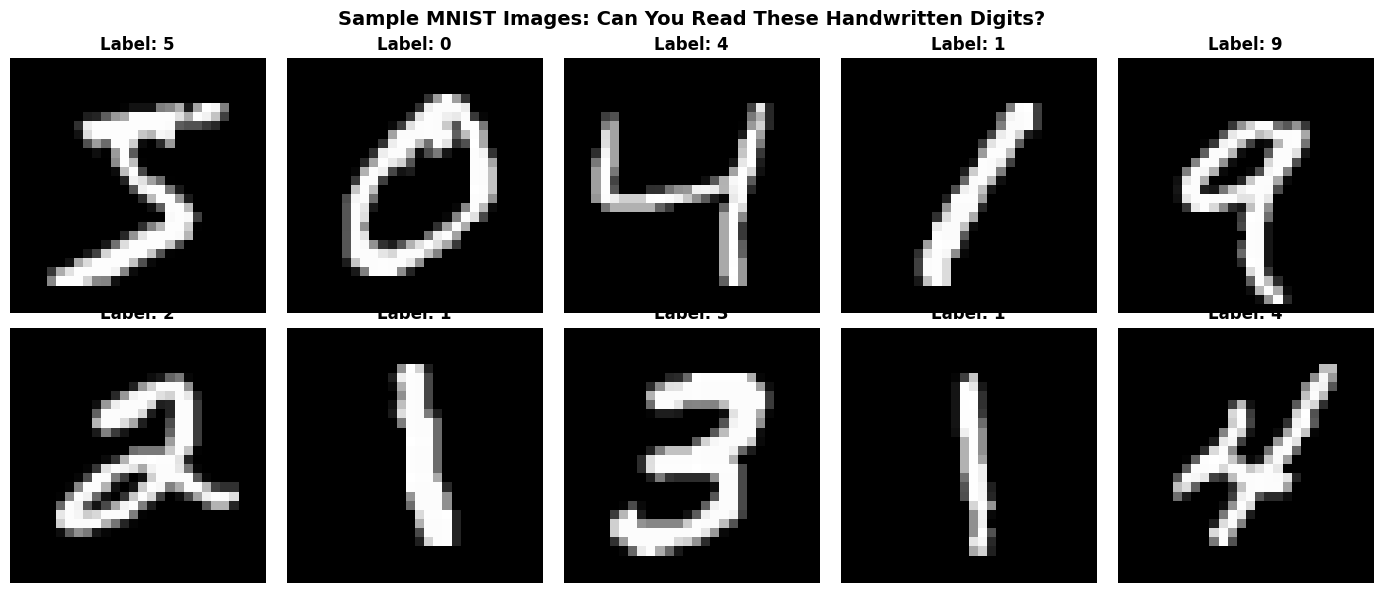


📊 Image Details:
   Shape: torch.Size([1, 28, 28])
   This means: 1 channel × 28 height × 28 width
   Label (the correct answer): 5
   Pixel value range: [-1.00, 1.00]


In [44]:
# Load the MNIST dataset 📚
# transforms.ToTensor() converts images to PyTorch tensors and scales pixels from 0-255 to 0-1
# transforms.Normalize() centers the data around 0 (helps training)

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to tensor and scales to [0, 1]
    transforms.Normalize((0.5,), (0.5,))  # Normalizes to [-1, 1]
])

# Download and load training data
print("Downloading MNIST dataset (this may take a moment)...")
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

print(f"\n✅ Dataset loaded!")
print(f"   Training images: {len(train_dataset):,}")
print(f"   Test images: {len(test_dataset):,}")

# Let's look at some sample images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flatten()):
    image, label = train_dataset[i]
    
    # Convert tensor back to numpy for display (undo normalization)
    img_display = image.squeeze().numpy() * 0.5 + 0.5  # Undo normalize
    
    ax.imshow(img_display, cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample MNIST Images: Can You Read These Handwritten Digits?', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show one image in detail
sample_image, sample_label = train_dataset[0]
print(f"\n📊 Image Details:")
print(f"   Shape: {sample_image.shape}")
print(f"   This means: {sample_image.shape[0]} channel × {sample_image.shape[1]} height × {sample_image.shape[2]} width")
print(f"   Label (the correct answer): {sample_label}")
print(f"   Pixel value range: [{sample_image.min():.2f}, {sample_image.max():.2f}]")


# Part 4: CNN Hyperparameters Explained 🎛️

Now let's explore the key settings (hyperparameters) that affect how a CNN works.

## 4.1 Kernel Size

The **kernel size** determines how big of a "window" the network looks at each time.

- **Small kernel (3×3):** Looks at tiny local patterns - good for fine details
- **Large kernel (7×7):** Looks at larger regions - good for bigger patterns

**Trade-off:** Larger kernels have more parameters and see more context, but may miss small details.


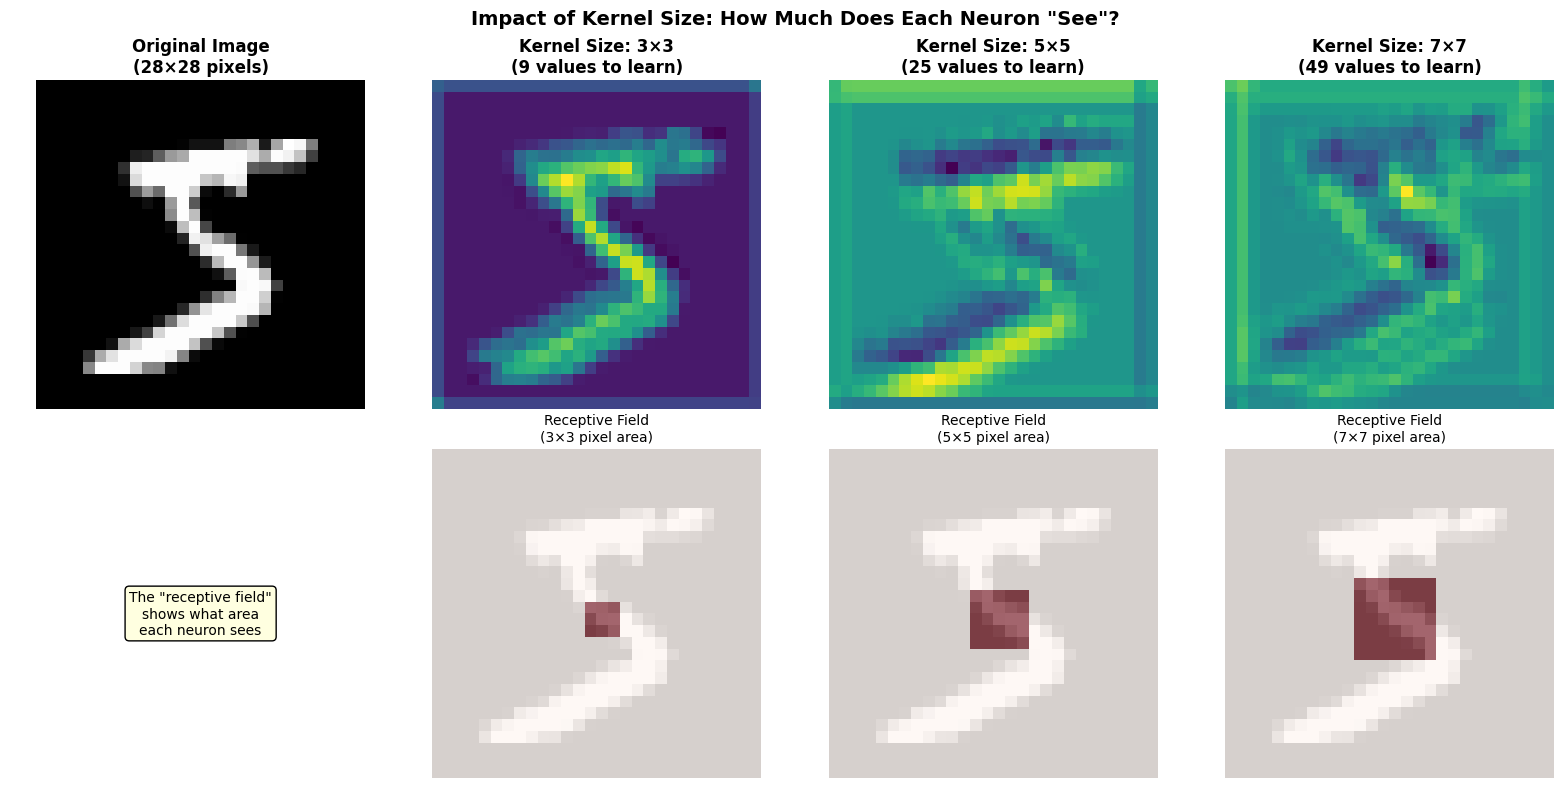

💡 KEY OBSERVATIONS:
   • 3×3 kernel: Looks at 9 pixels at a time - sees fine details
   • 5×5 kernel: Looks at 25 pixels - sees medium patterns
   • 7×7 kernel: Looks at 49 pixels - sees larger context

📝 In practice: Most modern CNNs use 3×3 kernels stacked in multiple layers
   This captures both local AND global patterns efficiently!


In [45]:
# Visualize the impact of different kernel sizes 🔬
def compare_kernel_sizes(image):
    """Show how different kernel sizes see the image differently"""
    kernel_sizes = [3, 5, 7]
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Original image
    axes[0, 0].imshow(image.squeeze().numpy() * 0.5 + 0.5, cmap='gray')
    axes[0, 0].set_title('Original Image\n(28×28 pixels)', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    axes[1, 0].axis('off')
    axes[1, 0].text(0.5, 0.5, 'The "receptive field"\nshows what area\neach neuron sees', 
                   ha='center', va='center', fontsize=10,
                   bbox=dict(boxstyle='round', facecolor='lightyellow'))
    
    for idx, k_size in enumerate(kernel_sizes):
        # Create a random conv layer with this kernel size
        conv = nn.Conv2d(1, 1, kernel_size=k_size, padding=k_size//2)
        
        with torch.no_grad():
            # Apply convolution
            output = conv(image.unsqueeze(0))
        
        # Show output
        axes[0, idx+1].imshow(output[0, 0].numpy(), cmap='viridis')
        axes[0, idx+1].set_title(f'Kernel Size: {k_size}×{k_size}\n({k_size*k_size} values to learn)', 
                                fontsize=12, fontweight='bold')
        axes[0, idx+1].axis('off')
        
        # Show receptive field (what area the kernel "sees")
        receptive_field = np.zeros((28, 28))
        center = 14
        half_k = k_size // 2
        receptive_field[center-half_k:center+half_k+1, center-half_k:center+half_k+1] = 1
        
        axes[1, idx+1].imshow(image.squeeze().numpy() * 0.5 + 0.5, cmap='gray', alpha=0.4)
        axes[1, idx+1].imshow(receptive_field, cmap='Reds', alpha=0.6)
        axes[1, idx+1].set_title(f'Receptive Field\n({k_size}×{k_size} pixel area)', fontsize=10)
        axes[1, idx+1].axis('off')
    
    plt.suptitle('Impact of Kernel Size: How Much Does Each Neuron "See"?', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("💡 KEY OBSERVATIONS:")
    print("   • 3×3 kernel: Looks at 9 pixels at a time - sees fine details")
    print("   • 5×5 kernel: Looks at 25 pixels - sees medium patterns")
    print("   • 7×7 kernel: Looks at 49 pixels - sees larger context")
    print("\n📝 In practice: Most modern CNNs use 3×3 kernels stacked in multiple layers")
    print("   This captures both local AND global patterns efficiently!")

# Use a sample from our dataset
compare_kernel_sizes(sample_image)


## 4.2 Number of Filters

Each convolutional layer can have multiple filters (kernels). Each filter learns to detect a DIFFERENT pattern!

- **Few filters (8):** Fast but might miss some patterns
- **Many filters (64):** Can detect more diverse patterns but slower

Think of it like having multiple experts, each looking for different things in the image.


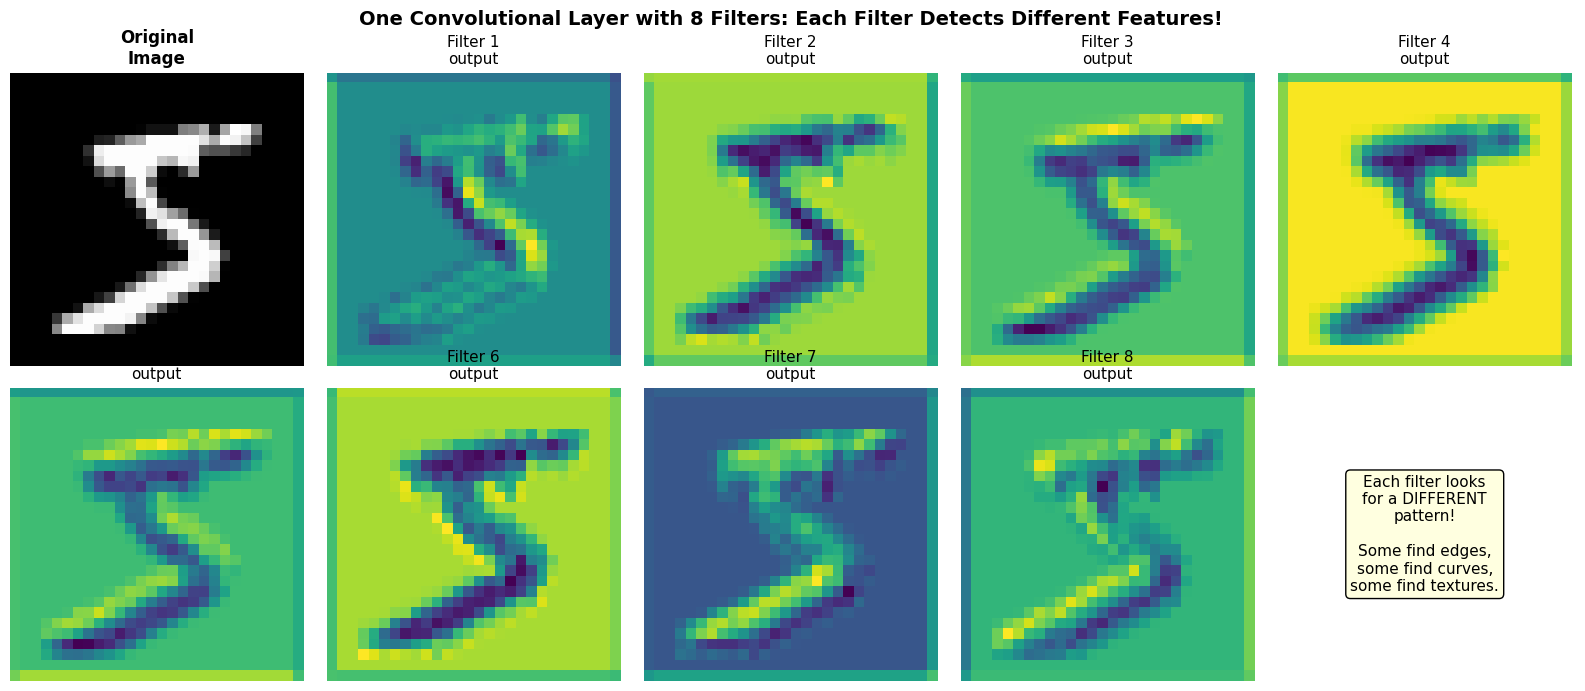

💡 KEY INSIGHT:
   • This single conv layer has 8 filters
   • Each filter produces a different 'feature map'
   • The network learns which patterns are useful for the task
   • More filters = more patterns detected = better (usually), but slower


In [46]:
# Visualize what multiple filters produce 🔎
def show_multiple_filters(image):
    """Show how different filters in the same layer detect different things"""
    num_filters = 8
    
    # Create a convolutional layer with 8 filters
    conv = nn.Conv2d(1, num_filters, kernel_size=3, padding=1)
    
    with torch.no_grad():
        # Apply all filters at once
        feature_maps = conv(image.unsqueeze(0))
    
    # Display results
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    
    # Original image in first position
    axes[0, 0].imshow(image.squeeze().numpy() * 0.5 + 0.5, cmap='gray')
    axes[0, 0].set_title('Original\nImage', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    # Show each filter's output
    for i in range(num_filters):
        row = (i + 1) // 5
        col = (i + 1) % 5
        
        axes[row, col].imshow(feature_maps[0, i].numpy(), cmap='viridis')
        axes[row, col].set_title(f'Filter {i+1}\noutput', fontsize=11)
        axes[row, col].axis('off')
    
    # Use the last cell for explanation
    axes[1, 4].axis('off')
    axes[1, 4].text(0.5, 0.5, 
                   'Each filter looks\nfor a DIFFERENT\npattern!\n\nSome find edges,\nsome find curves,\nsome find textures.',
                   ha='center', va='center', fontsize=11,
                   bbox=dict(boxstyle='round', facecolor='lightyellow'))
    
    plt.suptitle(f'One Convolutional Layer with {num_filters} Filters: Each Filter Detects Different Features!',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("💡 KEY INSIGHT:")
    print(f"   • This single conv layer has {num_filters} filters")
    print(f"   • Each filter produces a different 'feature map'")
    print(f"   • The network learns which patterns are useful for the task")
    print(f"   • More filters = more patterns detected = better (usually), but slower")

show_multiple_filters(sample_image)


# Part 5: Your Turn - Exercise! ✏️

Now it's time to put what you've learned into practice!

## Exercise: Complete This CNN and Train It

Below is a partially completed CNN for MNIST digit classification. Your task:

1. **Read through the code** and understand each part
2. **Fill in the missing parts** (marked with `# TODO`)
3. **Run the training** and see how well it does!

**Goal:** Achieve at least 95% accuracy on the test set (it's easier than you think!)


In [47]:
# ============================================================
# EXERCISE: Complete this CNN ✏️
# ============================================================

class MyCNN(nn.Module):
    """
    A simple CNN for classifying MNIST digits (0-9)
    
    Architecture:
        Input: 1 x 28 x 28 image
        → Conv1: 1 → 16 filters, 3x3 kernel, padding=1
        → ReLU
        → MaxPool 2x2 (now 16 x 14 x 14)
        → Conv2: 16 → 32 filters, 3x3 kernel, padding=1
        → ReLU  
        → MaxPool 2x2 (now 32 x 7 x 7)
        → Flatten (32 * 7 * 7 = 1568 features)
        → Fully Connected: 1568 → 10 (one output per digit class)
    """
    
    def __init__(self):
        super(MyCNN, self).__init__()
        
        # First convolutional layer
        # Input: 1 channel (grayscale), Output: 16 feature maps
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        
        # Second convolutional layer  
        # Input: 16 feature maps, Output: 32 feature maps
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
        # Max pooling layer (used after each conv)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully connected layer
        # After 2 pooling operations: 28 → 14 → 7
        # So we have 32 feature maps, each 7x7 = 32 * 7 * 7 = 1568 features
        self.fc = nn.Linear(32 * 7 * 7, 10)  # 10 output classes (digits 0-9)
    
    def forward(self, x):
        """
        Define how data flows through the network
        
        x shape: (batch_size, 1, 28, 28)
        """
        # First conv block: Conv → ReLU → Pool
        x = self.conv1(x)       # Shape: (batch, 16, 28, 28)
        x = F.relu(x)           # Apply ReLU activation
        x = self.pool(x)        # Shape: (batch, 16, 14, 14)
        
        # Second conv block: Conv → ReLU → Pool
        x = self.conv2(x)       # Shape: (batch, 32, 14, 14)
        x = F.relu(x)           # Apply ReLU activation
        x = self.pool(x)        # Shape: (batch, 32, 7, 7)
        
        # Flatten for fully connected layer
        x = x.view(-1, 32 * 7 * 7)  # Shape: (batch, 1568)
        
        # Final classification layer
        x = self.fc(x)          # Shape: (batch, 10)
        
        return x

# Create the model
model = MyCNN()

# Let's see what our model looks like!
print("🏗️ Your CNN Architecture:")
print(model)
print(f"\n📊 Total trainable parameters: {sum(p.numel() for p in model.parameters()):,}")
print("\nCompare this to a fully-connected network which would need:")
print(f"   First layer alone: 784 × 100 = {784 * 100:,} parameters!")


🏗️ Your CNN Architecture:
MyCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)

📊 Total trainable parameters: 20,490

Compare this to a fully-connected network which would need:
   First layer alone: 784 × 100 = 78,400 parameters!


In [48]:
# ============================================================
# TRAINING CODE - Run this to train your model! 🚀
# ============================================================

def train_model(model, train_dataset, test_dataset, epochs=3, batch_size=64):
    """
    Train the CNN model on MNIST
    
    This function:
    1. Creates data loaders (loads images in batches)
    2. Sets up the loss function and optimizer
    3. Trains for the specified number of epochs
    4. Evaluates on the test set
    """
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Loss function: CrossEntropyLoss is standard for classification
    criterion = nn.CrossEntropyLoss()
    
    # Optimizer: Adam is a good default choice
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Move model to GPU if available (makes training faster)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    print(f"Training on: {device}")
    
    # Training loop
    for epoch in range(epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            # Move data to device
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            optimizer.zero_grad()  # Clear previous gradients
            outputs = model(images)  # Get predictions
            loss = criterion(outputs, labels)  # Calculate loss
            
            # Backward pass
            loss.backward()  # Calculate gradients
            optimizer.step()  # Update weights
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # Print progress every 200 batches
            if batch_idx % 200 == 0:
                print(f'  Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')
        
        # Print epoch summary
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        print(f'Epoch {epoch+1}/{epochs}: Loss={epoch_loss:.4f}, Train Accuracy={epoch_acc:.2f}%')
    
    # Evaluate on test set
    model.eval()  # Set model to evaluation mode
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():  # Don't calculate gradients for evaluation
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
    
    test_acc = 100. * test_correct / test_total
    print(f'\n🎯 Final Test Accuracy: {test_acc:.2f}%')
    
    if test_acc >= 95:
        print("🎉 Congratulations! You achieved the goal of 95%+ accuracy!")
    
    return model

# Train the model! (This will take 1-2 minutes)
print("Starting training...\n")
trained_model = train_model(model, train_dataset, test_dataset, epochs=3)


Starting training...

Training on: cpu
  Batch 0/938, Loss: 2.2927
  Batch 200/938, Loss: 0.2957
  Batch 400/938, Loss: 0.0516
  Batch 600/938, Loss: 0.0984
  Batch 800/938, Loss: 0.0591
Epoch 1/3: Loss=0.2298, Train Accuracy=93.21%
  Batch 0/938, Loss: 0.0395
  Batch 200/938, Loss: 0.1840
  Batch 400/938, Loss: 0.3178
  Batch 600/938, Loss: 0.1206
  Batch 800/938, Loss: 0.1810
Epoch 2/3: Loss=0.0635, Train Accuracy=98.04%
  Batch 0/938, Loss: 0.0305
  Batch 200/938, Loss: 0.0585
  Batch 400/938, Loss: 0.0487
  Batch 600/938, Loss: 0.0718
  Batch 800/938, Loss: 0.0423
Epoch 3/3: Loss=0.0470, Train Accuracy=98.51%

🎯 Final Test Accuracy: 98.11%
🎉 Congratulations! You achieved the goal of 95%+ accuracy!


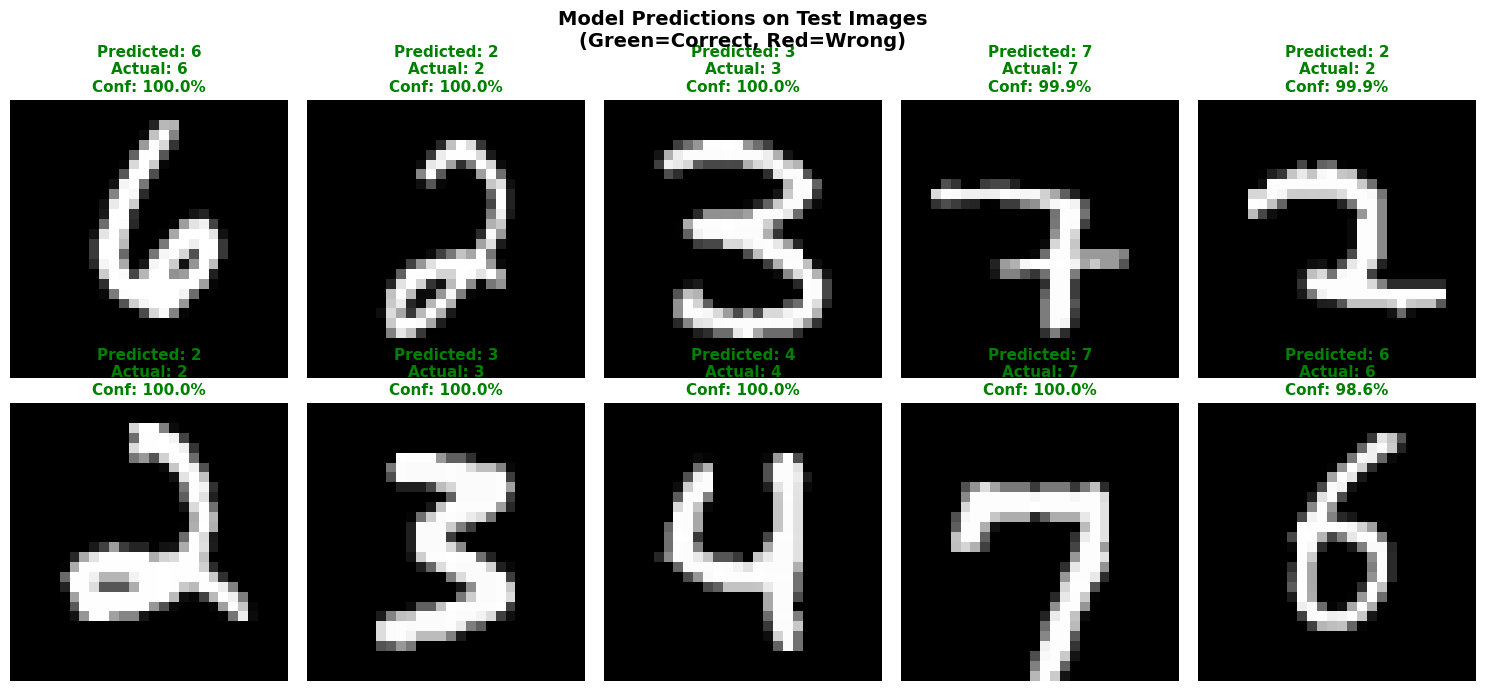

In [49]:
# ============================================================
# VISUALIZE PREDICTIONS 👀
# ============================================================

def show_predictions(model, test_dataset, num_samples=10):
    """Show some predictions from our trained model"""
    
    device = next(model.parameters()).device
    model.eval()
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    
    # Get random samples
    indices = np.random.choice(len(test_dataset), num_samples, replace=False)
    
    for idx, ax in zip(indices, axes.flatten()):
        image, true_label = test_dataset[idx]
        
        # Get prediction
        with torch.no_grad():
            output = model(image.unsqueeze(0).to(device))
            pred_label = output.argmax(1).item()
            confidence = F.softmax(output, dim=1).max().item()
        
        # Display
        ax.imshow(image.squeeze().numpy() * 0.5 + 0.5, cmap='gray')
        
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f'Predicted: {pred_label}\nActual: {true_label}\nConf: {confidence:.1%}',
                    color=color, fontsize=11, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle('Model Predictions on Test Images\n(Green=Correct, Red=Wrong)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Show some predictions!
show_predictions(trained_model, test_dataset)


---

# Summary & Key Takeaways 🎓

Congratulations on completing this tutorial! Let's recap what you've learned:

## 1. How Computers See Images
- Images are **grids of numbers** (pixels)
- Grayscale: 1 number per pixel (0-255)
- Color: 3 numbers per pixel (R, G, B)
- Shape notation: (Height × Width × Channels)

## 2. Classic Image Processing
- **Convolution**: Slide a kernel across the image, multiply and sum
- Different kernels detect different things (edges, blur, sharpen)
- These were **hand-designed** by humans

## 3. Convolutional Neural Networks (CNNs)
- **Same operation** as classic convolution, but kernels are **learned**!
- **Key layers:**
  - Convolutional: Detect patterns
  - ReLU: Add non-linearity
  - Pooling: Reduce size, add robustness
  - Fully Connected: Final classification

## 4. Why CNNs Work So Well for Images
- **Parameter sharing**: Same kernel used across whole image
- **Local connectivity**: Each neuron only looks at a small region
- **Hierarchical learning**: Early layers → edges, Later layers → complex shapes

## 5. Important Hyperparameters
| Parameter | What it controls | Typical values |
|-----------|-----------------|----------------|
| Kernel size | How much context each neuron sees | 3×3, 5×5 |
| Num filters | How many patterns to detect | 16, 32, 64, 128 |
| Pooling size | How much to downsample | 2×2 |
| Stride | How far to move each step | 1 or 2 |
| Padding | Whether to preserve size | 0 or 1 |

---

## What's Next?

Now that you understand the basics, explore these topics:

1. **Famous architectures**: LeNet, AlexNet, VGG, ResNet, EfficientNet
2. **Transfer learning**: Use pre-trained models for your tasks
3. **Data augmentation**: Make models more robust
4. **Object detection**: YOLO, Faster R-CNN
5. **Semantic segmentation**: U-Net, DeepLab

## Resources for Further Learning
- [CS231n: CNNs for Visual Recognition](http://cs231n.stanford.edu/) - Stanford's famous course
- [PyTorch Tutorials](https://pytorch.org/tutorials/) - Official tutorials
- [Distill.pub](https://distill.pub/) - Beautiful visual explanations
- [3Blue1Brown Neural Networks](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) - Excellent videos

---

**Great job! You now understand the fundamentals of image processing and CNNs.** 🚀

Questions? Experiment with the code above and see what you discover!
